# Getting to knOW the Data
- SAR Data only from 2016-2023
- 3 types of crops mostly. Only focus on corn, wheat and soybeans
- yield is our raw target variable
- irregular time observations, Need models to accomodate that
- have 4 datasets - corn wheat soy together and seperate
-normalize yield indivisually according to crop type for each year in the dataset of all together
-40 and 60 percentile dive
- train test split according to farms

# Observation
* normalize the data based on year. If one year has more samples, then it will we will give it a small weight and if it has less sample then we will weight it more
* train on 2016-2020, validate 2021 and test on 2022-2023
* Completely different from my URSA Space Systems project. ViT and Swin Transformer can only be used on image data to convert it into vectors

In [1]:
#import pandas as pd
#from pathlib import Path
import numpy as np
import pyarrow as pyr
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import warnings
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
 
# -------- USER SETTINGS --------


LAT_COL = "latitude"

LON_COL = "longitude"

VALUE_COL = "VH_029"   # <-- change this

# -------------------------------
 
# Load only what we need

df = pd.read_parquet("data/combined_data_2016_2023_corn_wheat_soy.parquet", columns=[LAT_COL, LON_COL, VALUE_COL, "Year"])
 
# Drop missing values

df_2016 = df[df["Year"] == "2018"]

df = df_2016.copy()
 
# Plot

plt.figure(figsize=(8, 8))

plt.scatter(

    df[LON_COL],

    df[LAT_COL],

    c=df[VALUE_COL],

    s=2,

    cmap="viridis"

)
 
plt.colorbar(label=VALUE_COL)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title(VALUE_COL)

plt.gca().set_aspect("equal")

plt.show()

 

ArrowInvalid: No match for FieldRef.Name(VH_029) in farm_name: string
longitude: double
latitude: double
pixel_id: int64
Year: int64
crop: string
yield: double
normalized_yield_pct: double
normalized_yield_z: double
growing_seasons_N: int64
yield_zone: double
yield_stability_zone: double
DEM: double
slope_deg: double
aspect_deg: double
shape_index: double
soil_bulk_density: double
soil_clay: double
soil_sand: double
soil_silt: double
soil_soilorganiccarbon: double
prcp_04: double
prcp_05: double
prcp_06: double
prcp_07: double
prcp_08: double
prcp_09: double
prcp_10: double
prcp_season: double
srad_04: double
srad_05: double
srad_06: double
srad_07: double
srad_08: double
srad_09: double
srad_10: double
srad_season: double
gdd_04: double
gdd_05: double
gdd_06: double
gdd_07: double
gdd_08: double
gdd_09: double
gdd_10: double
gdd_season: double
VH_0102: double
VH_0104: double
VH_0107: double
VH_0109: double
VH_0110: double
VH_0114: double
VH_0116: double
VH_0119: double
VH_0121: double

# STEP 1: LOADING PARQUET FILES


In [6]:
# from pathlib import Path
# import pyarrow as pa
# import pyarrow.parquet as pq

# input_dir = Path("data/gamma_k8")
# output_file = Path("data/combined_data.parquet")

# parquet_files = sorted(input_dir.glob("*.parquet"))

# if not parquet_files:
#     raise RuntimeError("No parquet files found")

# print(f"Found {len(parquet_files)} parquet files")

# # Read first file to establish canonical schema
# first_table = pq.read_table(parquet_files[0])
# canonical_schema = first_table.schema

# writer = pq.ParquetWriter(output_file, canonical_schema)

# def align_table(table, schema):
#     """Align a PyArrow table to a target schema."""
#     cols = {}

#     for field in schema:
#         name = field.name
#         if name in table.schema.names:
#             col = table[name]

#             # Cast if needed
#             if not col.type.equals(field.type):
#                 col = col.cast(field.type)

#             cols[name] = col
#         else:
#             # Missing column → fill with nulls
#             cols[name] = pa.nulls(len(table), type=field.type)

#     return pa.table(cols, schema=schema)

# # Write first file
# writer.write_table(first_table)

# # Process remaining files
# for i, file in enumerate(parquet_files[1:], start=2):
#     table = pq.read_table(file)
#     table = align_table(table, canonical_schema)
#     writer.write_table(table)

#     if i % 25 == 0 or i == len(parquet_files):
#         print(f"Processed {i}/{len(parquet_files)} files")

# writer.close()

# print("✅ DONE")
# print("Output written to:", output_file)


Found 328 parquet files
Processed 25/328 files
Processed 50/328 files
Processed 75/328 files
Processed 100/328 files
Processed 125/328 files
Processed 150/328 files
Processed 175/328 files
Processed 200/328 files
Processed 225/328 files
Processed 250/328 files
Processed 275/328 files
Processed 300/328 files
Processed 325/328 files
Processed 328/328 files
✅ DONE
Output written to: data/combined_data.parquet


In [3]:
# df = pd.read_parquet("data/combined_data.parquet")
# df.shape

(17485047, 369)

In [10]:
# df.head()

,farm_name,longitude,latitude,pixel_id,Year,crop,yield,normalized_yield_pct,normalized_yield_z,growing_seasons_N,...,VV_1205,VV_1209,VV_1211,VV_1214,VV_1216,VV_1221,VV_1223,VV_1226,VV_1228,VV_1229
0,100_Cort,-84.707734,42.407353,0,2016,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100_Cort,-84.707644,42.407353,1,2016,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100_Cort,-84.707554,42.407353,2,2016,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100_Cort,-84.707464,42.407353,3,2016,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100_Cort,-84.707375,42.407353,4,2016,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# df["Year"].unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2008, 2002, 2024, 2007, 2005, 2006, 2003])

# Filter out all year and crop other than 2016-2023 and corn, wheat, soybean and make a combined filtered dataset

In [5]:
# input_file = "data/combined_data.parquet"
# output_file = "data/combined_data_2016_2023_corn_wheat_soy.parquet"

# dataset = ds.dataset(input_file, format="parquet")

# # Filters
# year_filter = (ds.field("Year") >= 2016) & (ds.field("Year") <= 2023)

# crop_filter = (
#     ds.field("crop").is_valid() & (
#         (ds.field("crop") == "corn") |
#         (ds.field("crop") == "wheat") |
#         (ds.field("crop") == "soybeans")
#     )
# )

# final_filter = year_filter & crop_filter

# print("Filtering dataset...")

# table = dataset.to_table(filter=final_filter)

# print("Filtered rows:", table.num_rows)
# print("Writing filtered dataset...")

# pq.write_table(
#     table,
#     output_file,
#     compression="snappy"
# )

# print("✅ DONE")
# print("Output written to:", output_file)

In [19]:
df = pd.read_parquet("data/combined_data_2016_2023_corn_wheat_soy.parquet")
df

,farm_name,longitude,latitude,pixel_id,Year,crop,yield,normalized_yield_pct,normalized_yield_z,growing_seasons_N,...,VV_1205,VV_1209,VV_1211,VV_1214,VV_1216,VV_1221,VV_1223,VV_1226,VV_1228,VV_1229
0,100_Cort,-84.706746,42.407264,106,2021,corn,70.254074,-0.493450,-2.315856,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100_Cort,-84.706656,42.407264,107,2021,corn,69.660706,-0.497728,-2.335935,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100_Cort,-84.706566,42.407264,108,2021,corn,72.203461,-0.479395,-2.249890,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100_Cort,-84.706476,42.407264,109,2021,corn,77.535706,-0.440948,-2.069452,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100_Cort,-84.706386,42.407264,110,2021,corn,85.045502,-0.386800,-1.815327,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3299030,unknown_2,-85.189194,43.192213,1343,2022,corn,173.057831,0.066905,0.417660,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3299031,unknown_2,-85.189104,43.192213,1344,2022,corn,170.765610,0.052774,0.329442,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3299032,unknown_2,-85.189014,43.192213,1345,2022,corn,165.963333,0.023168,0.144625,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3299033,unknown_2,-85.188924,43.192213,1346,2022,corn,160.642441,-0.009636,-0.060152,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Create 3 seperate dataset for 3 different crops

In [6]:
# import pyarrow.dataset as ds
# import pyarrow.parquet as pq

# input_file = "data/combined_data.parquet"

# output_files = {
#     "corn": "data/corn_2016_2023.parquet",
#     "wheat": "data/wheat_2016_2023.parquet",
#     "soybeans": "data/soybeans_2016_2023.parquet",
# }

# dataset = ds.dataset(input_file, format="parquet")

# # Common year filter
# year_filter = (ds.field("Year") >= 2016) & (ds.field("Year") <= 2023)

# for crop, out_file in output_files.items():
#     print(f"Processing {crop}...")

#     crop_filter = (
#         ds.field("crop").is_valid() &
#         (ds.field("crop") == crop)
#     )

#     final_filter = year_filter & crop_filter

#     table = dataset.to_table(filter=final_filter)

#     print(f"  Rows: {table.num_rows}")

#     pq.write_table(
#         table,
#         out_file,
#         compression="snappy"
#     )

#     print(f"  ✅ Written to {out_file}\n")

# print("🎉 All crop-specific datasets created!")


Processing corn...
  Rows: 2108996
  ✅ Written to data/corn_2016_2023.parquet

Processing wheat...
  Rows: 495789
  ✅ Written to data/wheat_2016_2023.parquet

Processing soybeans...
  Rows: 694250
  ✅ Written to data/soybeans_2016_2023.parquet

🎉 All crop-specific datasets created!


In [7]:
pd.read_parquet("data/soybeans_2016_2023.parquet")["crop"].unique()

<ArrowStringArray>
['soybeans']
Length: 1, dtype: str

In [9]:
pd.read_parquet("data/soybeans_2016_2023.parquet")["Year"].unique()

array([2022, 2018, 2021, 2016, 2020, 2017, 2019])

In [10]:
files = [
    "data/corn_2016_2023.parquet",
    "data/wheat_2016_2023.parquet",
    "data/soybeans_2016_2023.parquet"
]

for file in files:
    df = pd.read_parquet(file)
    df = df[df["yield"].notna()]
    df["normalized_yield"] = (df["yield"] - df["yield"].mean()) / df["yield"].std()
    percentiles = df["yield"].quantile([0.4, 0.6])
    low, high = percentiles.loc[0.4], percentiles.loc[0.6]
    df["yield_category"] = df["yield"].apply(lambda y: "low" if y < low else "medium" if y <= high else "high")
    df.to_parquet(file, compression="snappy", index=False)
    print(f"✅ Updated {file}")


✅ Updated data/corn_2016_2023.parquet
✅ Updated data/wheat_2016_2023.parquet
✅ Updated data/soybeans_2016_2023.parquet


In [11]:
pd.read_parquet("data/soybeans_2016_2023.parquet").head()

,farm_name,longitude,latitude,pixel_id,Year,crop,yield,normalized_yield_pct,normalized_yield_z,growing_seasons_N,...,VV_1211,VV_1214,VV_1216,VV_1221,VV_1223,VV_1226,VV_1228,VV_1229,normalized_yield,yield_category
0,100_Cort,-84.706656,42.407264,107,2022,soybeans,36.645161,-0.372412,-2.518124,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.052265,low
1,100_Cort,-84.706566,42.407264,108,2022,soybeans,38.027645,-0.348736,-2.358031,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.951817,low
2,100_Cort,-84.706476,42.407264,109,2022,soybeans,41.341869,-0.291976,-1.974242,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.711013,low
3,100_Cort,-84.706386,42.407264,110,2022,soybeans,46.206684,-0.208661,-1.410893,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.357548,low
4,100_Cort,-84.706297,42.407264,111,2022,soybeans,51.142426,-0.124131,-0.839330,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001071,medium


# Visualization

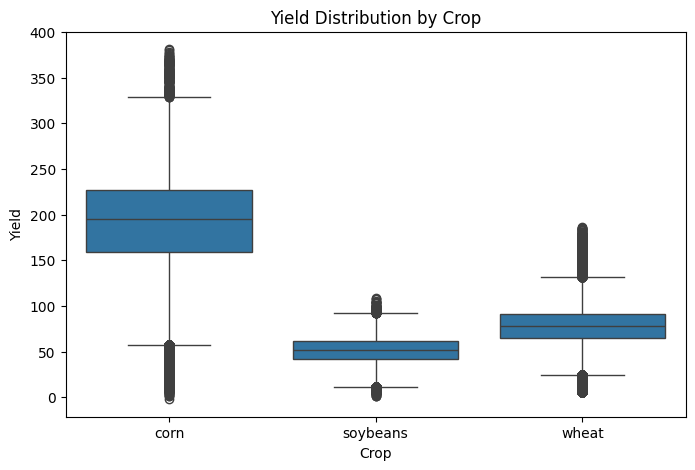

In [18]:
import seaborn as sns
cols = ["Year", "crop", "yield", "latitude", "longitude"]

df = pd.read_parquet(
    "data/combined_data_2016_2023_corn_wheat_soy.parquet",
    columns=cols
)

#viz_df = df.sample(n=200_000, random_state=42)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="crop",
    y="yield"
)

plt.title("Yield Distribution by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield")
plt.show()


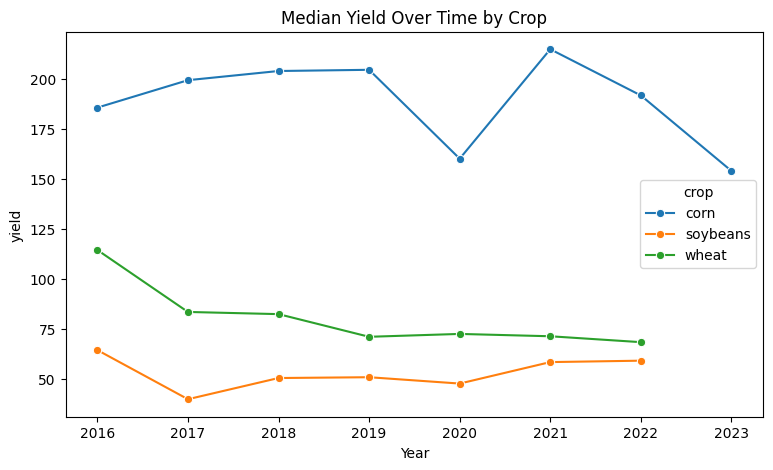

In [17]:
yearly = (
    df.groupby(["Year", "crop"])["yield"]
      .median()
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=yearly,
    x="Year",
    y="yield",
    hue="crop",
    marker="o"
)

plt.title("Median Yield Over Time by Crop")
plt.show()


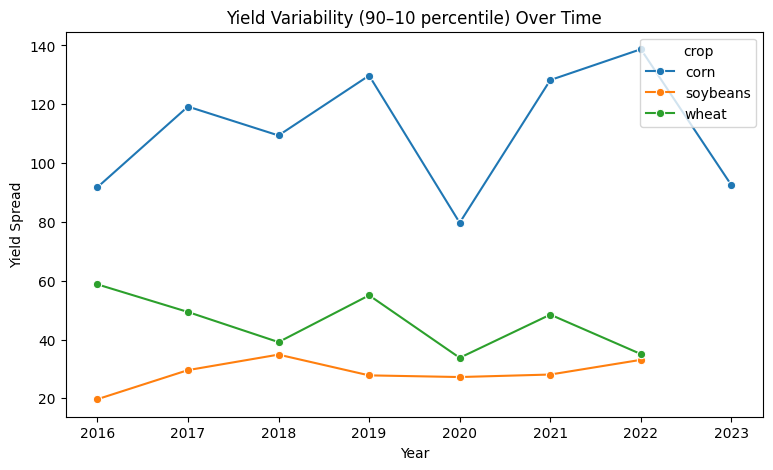

In [19]:
spread = (
    df.groupby(["Year", "crop"])["yield"]
      .quantile([0.1, 0.9])
      .unstack()
      .reset_index()
)

spread["iqr"] = spread[0.9] - spread[0.1]

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=spread,
    x="Year",
    y="iqr",
    hue="crop",
    marker="o"
)

plt.title("Yield Variability (90–10 percentile) Over Time")
plt.ylabel("Yield Spread")
plt.show()


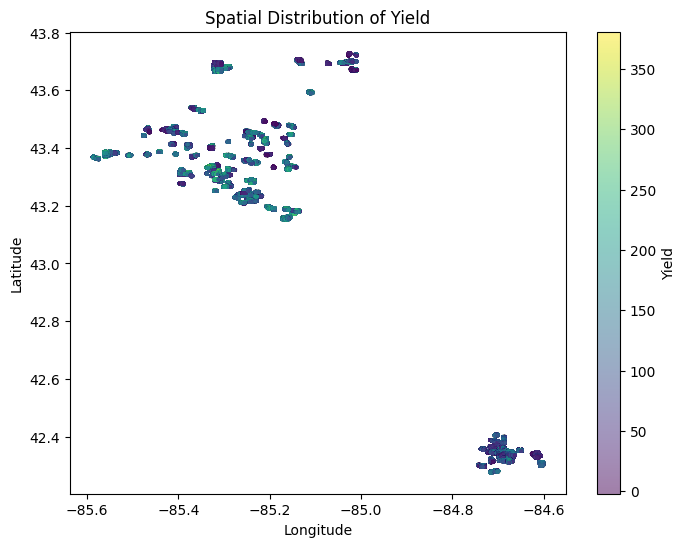

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["yield"],
    cmap="viridis",
    s=2,
    alpha=0.5
)

plt.colorbar(label="Yield")
plt.title("Spatial Distribution of Yield")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


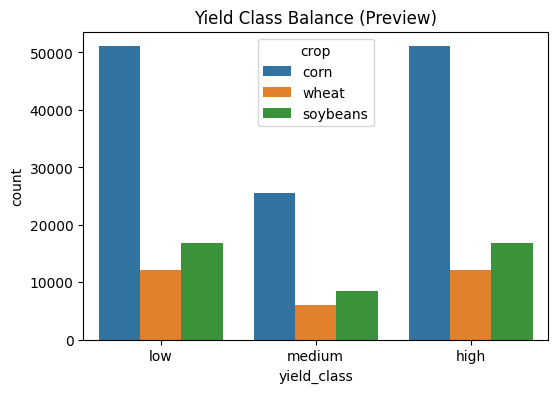

In [24]:
def label_yield(x):
    if x < 0.4:
        return "low"
    elif x <= 0.6:
        return "medium"
    else:
        return "high"

tmp = viz_df.copy()
tmp["yield_pct"] = tmp.groupby("crop")["yield"].rank(pct=True)
tmp["yield_class"] = tmp["yield_pct"].apply(label_yield)

plt.figure(figsize=(6, 4))
sns.countplot(
    data=tmp,
    x="yield_class",
    hue="crop"
)

plt.title("Yield Class Balance (Preview)")
plt.show()


Plotting 380,070 points


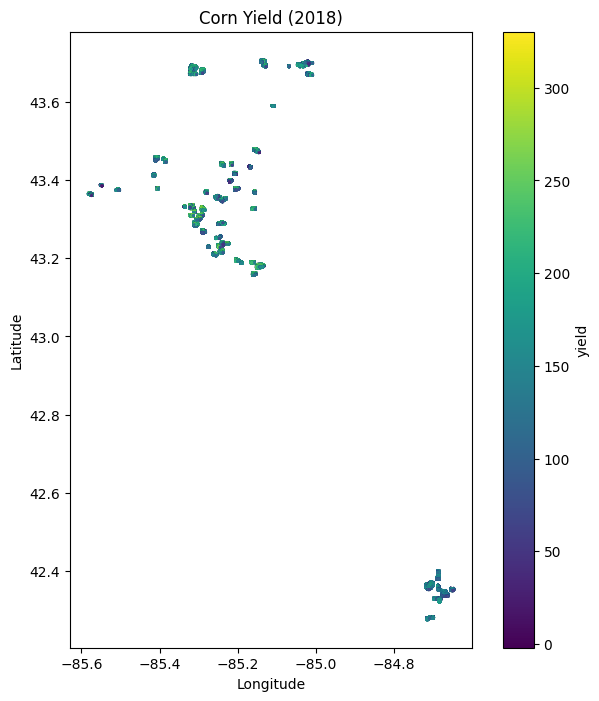

In [27]:
# -------- USER SETTINGS --------
PARQUET_PATH = "data/combined_data_2016_2023_corn_wheat_soy.parquet"

LAT_COL = "latitude"
LON_COL = "longitude"
VALUE_COL = "yield"
YEAR = 2018          # change if you want
CROP = "corn"        # "corn", "wheat", "soybeans"
# -------------------------------

# Load only required columns (IMPORTANT)
df = pd.read_parquet(
    PARQUET_PATH,
    columns=[LAT_COL, LON_COL, VALUE_COL, "Year", "crop"]
)

# Filter
df = df[(df["Year"] == YEAR) & (df["crop"] == CROP)]

print(f"Plotting {len(df):,} points")

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(
    df[LON_COL],
    df[LAT_COL],
    c=df[VALUE_COL],
    s=1,
    cmap="viridis"
)

plt.colorbar(label=VALUE_COL)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{CROP.capitalize()} Yield ({YEAR})")
plt.gca().set_aspect("equal")
plt.show()


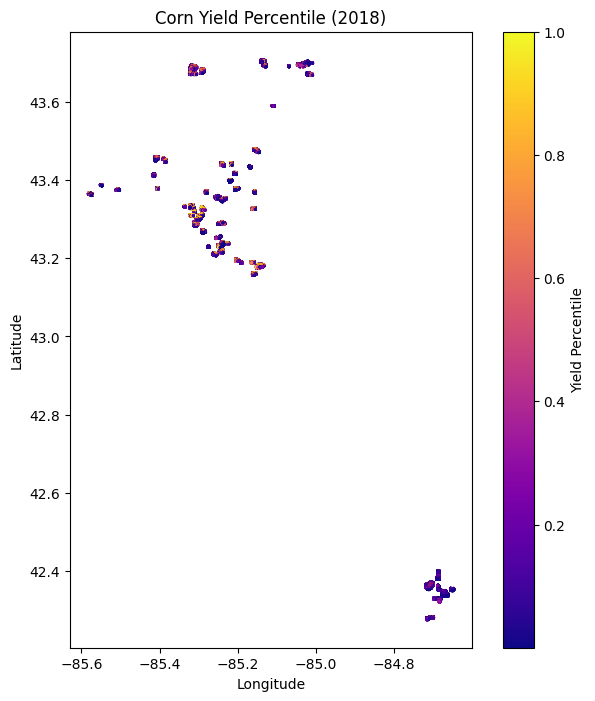

In [28]:
# Compute percentile WITHIN CROP & YEAR
df["yield_pct"] = (
    df[VALUE_COL]
    .rank(pct=True)
)

plt.figure(figsize=(8, 8))
plt.scatter(
    df[LON_COL],
    df[LAT_COL],
    c=df["yield_pct"],
    s=1,
    cmap="plasma"
)

plt.colorbar(label="Yield Percentile")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{CROP.capitalize()} Yield Percentile ({YEAR})")
plt.gca().set_aspect("equal")
plt.show()


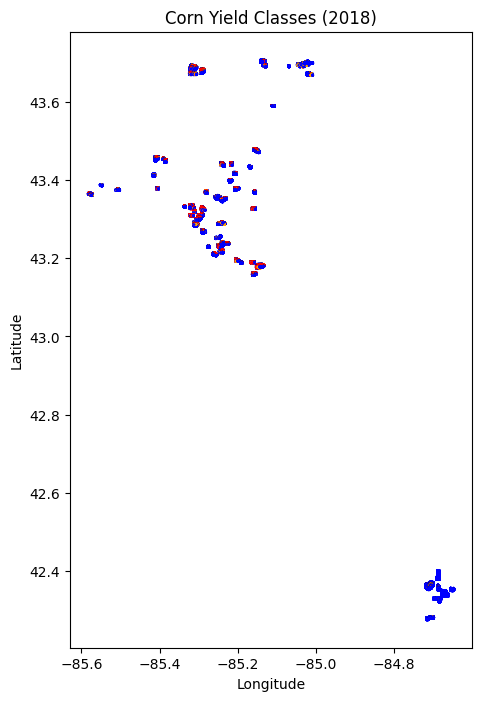

In [29]:
def yield_class(p):
    if p < 0.4:
        return "low"
    elif p <= 0.6:
        return "medium"
    else:
        return "high"

df["yield_class"] = df["yield_pct"].apply(yield_class)

color_map = {"low": "blue", "medium": "orange", "high": "red"}

plt.figure(figsize=(8, 8))
plt.scatter(
    df[LON_COL],
    df[LAT_COL],
    c=df["yield_class"].map(color_map),
    s=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{CROP.capitalize()} Yield Classes ({YEAR})")
plt.gca().set_aspect("equal")
plt.show()


In [30]:
df["yield_pct"] = df["yield"].rank(pct=True)
print(df["yield"].describe())
print(df["yield_pct"].describe())


count    380070.000000
mean        197.507855
std          44.081325
min          -2.071184
25%         169.499718
50%         203.928535
75%         230.423500
max         330.231079
Name: yield, dtype: float64
count    380070.000000
mean          0.500001
std           0.288676
min           0.000003
25%           0.250001
50%           0.500001
75%           0.750001
max           1.000000
Name: yield_pct, dtype: float64


In [6]:
import pandas as pd
import numpy as np
import os

def process_crop_data(crop_name):
    file_path = f"data/{crop_name}_2016_2023.parquet"
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping.")
        return

    print(f"--- Processing {crop_name.upper()} ---")
    df = pd.read_parquet(file_path)
    
    # 1. Identify all SAR columns
    all_sar = [c for c in df.columns if c.startswith(("VV_", "VH_"))]
    
    # 2. Define valid months
    if crop_name.lower() in ["corn", "soybeans"]:
        valid_months = ["06", "07", "08", "09", "10"]
    elif crop_name.lower() == "wheat":
        valid_months = ["05", "06", "07"]
    else:
        print(f"Unknown crop {crop_name}. Skipping filtering.")
        return

    # 3. Separate columns to keep vs. columns to drop
    to_keep = [c for c in all_sar if c.split('_')[1][:2] in valid_months]
    to_drop = [c for c in all_sar if c not in to_keep]
    
    df = df.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} columns outside growing season. Kept {len(to_keep)} columns.")

    # 4. Add Polarization Ratio (PR) and Radar Vegetation Index (RVI)
    # Get the unique dates available in the filtered set
    dates = sorted(list(set([c.split('_')[1] for c in to_keep])))
    
    print(f"Calculating PR and RVI for {len(dates)} dates...")
    for d in dates:
        vv_col = f"VV_{d}"
        vh_col = f"VH_{d}"
        
        if vv_col in df.columns and vh_col in df.columns:
            # Polarization Ratio (VH/VV)
            df[f"PR_{d}"] = (df[vh_col] / (df[vv_col] + 1e-6)).astype(np.float32)
            
            # Radar Vegetation Index (Dual-Pol RVI: 4*VH / (VV + VH))
            df[f"RVI_{d}"] = ((4 * df[vh_col]) / (df[vv_col] + df[vh_col] + 1e-6)).astype(np.float32)

    # 5. Overwrite the file (or save as _processed if you want a backup)
    save_path = f"data/{crop_name}_2016_2023_processed.parquet"
    df.to_parquet(save_path)
    print(f"Saved processed data to {save_path}\n")

# Run for all three
for crop in ["corn", "soybeans", "wheat"]:
    process_crop_data(crop)

--- Processing CORN ---
Dropped 180 columns outside growing season. Kept 144 columns.
Calculating PR and RVI for 66 dates...


/tmp/ipykernel_1689774/1137630925.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"PR_{d}"] = (df[vh_col] / (df[vv_col] + 1e-6)).astype(np.float32)
/tmp/ipykernel_1689774/1137630925.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"RVI_{d}"] = ((4 * df[vh_col]) / (df[vv_col] + df[vh_col] + 1e-6)).astype(np.float32)
/tmp/ipykernel_1689774/1137630925.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joi

Saved processed data to data/corn_2016_2023_processed.parquet

--- Processing SOYBEANS ---
Dropped 180 columns outside growing season. Kept 144 columns.
Calculating PR and RVI for 66 dates...


/tmp/ipykernel_1689774/1137630925.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"PR_{d}"] = (df[vh_col] / (df[vv_col] + 1e-6)).astype(np.float32)
/tmp/ipykernel_1689774/1137630925.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"RVI_{d}"] = ((4 * df[vh_col]) / (df[vv_col] + df[vh_col] + 1e-6)).astype(np.float32)
/tmp/ipykernel_1689774/1137630925.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joi

Saved processed data to data/soybeans_2016_2023_processed.parquet

--- Processing WHEAT ---
Dropped 236 columns outside growing season. Kept 88 columns.
Calculating PR and RVI for 40 dates...
Saved processed data to data/wheat_2016_2023_processed.parquet



In [3]:
meow = pd.read_parquet("data/soybeans_2016_2023_processed.parquet")
# for i in meow.columns:
#     print(i)
meow.head()

,farm_name,longitude,latitude,pixel_id,Year,crop,yield,normalized_yield_pct,normalized_yield_z,growing_seasons_N,...,PR_1024,RVI_1024,PR_1025,RVI_1025,PR_1027,RVI_1027,PR_1029,RVI_1029,PR_1030,RVI_1030
0,100_Cort,-84.706656,42.407264,107,2022,soybeans,36.645161,-0.372412,-2.518124,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100_Cort,-84.706566,42.407264,108,2022,soybeans,38.027645,-0.348736,-2.358031,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100_Cort,-84.706476,42.407264,109,2022,soybeans,41.341869,-0.291976,-1.974242,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100_Cort,-84.706386,42.407264,110,2022,soybeans,46.206684,-0.208661,-1.410893,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100_Cort,-84.706297,42.407264,111,2022,soybeans,51.142426,-0.124131,-0.839330,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1]:
import pandas as pd
meow = pd.read_parquet("data/gamma_k8_stacked_ablated_corn_wheat_soy.parquet")
meow.head()


,farm_name,longitude,latitude,pixel_id,Year,crop,yield,normalized_yield_pct,normalized_yield_z,growing_seasons_N,...,VV_1127_2,VV_1129_2,VV_1130_2,VV_1202_2,VV_1205_2,VV_1209_2,VV_1213_2,VV_1214_2,VV_1226_2,VV_1229_2
0,100_Cort,-84.706746,42.407264,106,2021,corn,70.254074,-0.493450,-2.315856,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100_Cort,-84.706656,42.407264,107,2021,corn,69.660706,-0.497728,-2.335935,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100_Cort,-84.706566,42.407264,108,2021,corn,72.203461,-0.479395,-2.249890,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100_Cort,-84.706476,42.407264,109,2021,corn,77.535706,-0.440948,-2.069452,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100_Cort,-84.706386,42.407264,110,2021,corn,85.045502,-0.386800,-1.815327,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
for i in meow.columns:
    print(i)

farm_name
longitude
latitude
pixel_id
Year
crop
yield
normalized_yield_pct
normalized_yield_z
growing_seasons_N
yield_zone
yield_stability_zone
DEM
slope_deg
aspect_deg
shape_index
soil_bulk_density
soil_clay
soil_sand
soil_silt
soil_soilorganiccarbon
prcp_04
prcp_05
prcp_06
prcp_07
prcp_08
prcp_09
prcp_10
prcp_season
srad_04
srad_05
srad_06
srad_07
srad_08
srad_09
srad_10
srad_season
gdd_04
gdd_05
gdd_06
gdd_07
gdd_08
gdd_09
gdd_10
gdd_season
VH_0102
VH_0104
VH_0107
VH_0109
VH_0110
VH_0114
VH_0116
VH_0119
VH_0119_2
VH_0121
VH_0122
VH_0126
VH_0128
VH_0131
VH_0202
VH_0203
VH_0207
VH_0209
VH_0212
VH_0212_2
VH_0214
VH_0219
VH_0221
VH_0224
VH_0224_2
VH_0226
VH_0227
VH_0303
VH_0304
VH_0308
VH_0310
VH_0311
VH_0315
VH_0316
VH_0319_2
VH_0322
VH_0328
VH_0401
VH_0403
VH_0404
VH_0408
VH_0409
VH_0415
VH_0420
VH_0421
VH_0424_2
VH_0425
VH_0427
VH_0428
VH_0502
VH_0503
VH_0507
VH_0509
VH_0510
VH_0514
VH_0515
VH_0518
VH_0519
VH_0521
VH_0522
VH_0526
VH_0527
VH_0530
VH_0531
VH_0603
VH_0607
VH_0608
VH_061